# Import PyTorch

In [1]:
import torch
import numpy as np

In [2]:
torch.__version__

'2.10.0+cu128'

## Tensor

### Create tensor

In [3]:
x = torch.tensor(7)
x

tensor(7)

In [4]:
x.data, x.ndim, x.shape, x.item()

(tensor(7), 0, torch.Size([]), 7)

- `data` to get tensor data
- `ndim` to get tensor dimension number. eg 0 for scalar, 1 for vector, 2 for 2d matix...
- `shape` to get the shape of your tensor
- `item` for the value inside your tensor (only for tensor of ndim==0)

In [5]:
torch.tensor(np.random.randint(0,100,(24,24,3))).shape

torch.Size([24, 24, 3])

You can also specify the type of data inside the tensor

In [6]:
torch.tensor(np.random.randint(0,10,(3,3,3)), dtype=torch.int)

tensor([[[0, 9, 7],
         [1, 5, 0],
         [3, 6, 7]],

        [[6, 0, 6],
         [6, 7, 1],
         [7, 4, 2]],

        [[6, 1, 0],
         [4, 8, 5],
         [6, 6, 4]]], dtype=torch.int32)

In [7]:
TENSOR = torch.tensor([[[1, 2, 3],
                        [3, 6, 9],
                        [2, 4, 5]],
                        [[4, 9, 2],
                        [8, 2, 8],
                        [6, 9, 1]]], dtype=torch.float)

In [8]:
TENSOR.shape, TENSOR.ndim, TENSOR.var(dim=2), TENSOR.mean(dim=2), TENSOR.median(dim=2)

(torch.Size([2, 3, 3]),
 3,
 tensor([[ 1.0000,  9.0000,  2.3333],
         [13.0000, 12.0000, 16.3333]]),
 tensor([[2.0000, 6.0000, 3.6667],
         [5.0000, 6.0000, 5.3333]]),
 torch.return_types.median(
 values=tensor([[2., 6., 4.],
         [4., 8., 6.]]),
 indices=tensor([[1, 1, 1],
         [0, 0, 0]])))

In [9]:
x = torch.randint(0,100,(1,10), dtype=torch.float).reshape(-1)
x

tensor([56., 22., 71., 17., 81., 26., 20., 74., 76., 95.])

In [10]:
print(f"-> Size = {x.size()[0]}")
print(f"-> Min = {x.min()}")
print(f"-> Max = {x.max()}")
print(f"-> Mean = {x.mean():.3f}")
print(f"-> Std = {x.std():.3f}")
print(f"-> ArgMin = {x.argmin()}")
print(f"-> ArgMax = {x.argmax()}")

-> Size = 10
-> Min = 17.0
-> Max = 95.0
-> Mean = 53.800
-> Std = 29.664
-> ArgMin = 3
-> ArgMax = 9


In [11]:
# Default datatype for tensors is float32
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # defaults to None, which is torch.float32 or whatever datatype is passed
                               device=None, # defaults to None, which uses the default tensor type
                               requires_grad=False) # if True, operations performed on the tensor are recorded 

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

In [12]:
#Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: gpu
torch.device('cuda')

#You can check if cuda is available using
cuda_available = torch.cuda.is_available()

print(f"CUDA Available: {cuda_available}")

CUDA Available: False


In [13]:
tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=torch.float64,
                               device=torch.device('cpu'),
                               requires_grad=False)

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

### Random tensor

In [14]:
torch.rand((10,5))

tensor([[0.9328, 0.6811, 0.2350, 0.7816, 0.7292],
        [0.4365, 0.2576, 0.6891, 0.1721, 0.7497],
        [0.7251, 0.4567, 0.4604, 0.9354, 0.7768],
        [0.2258, 0.8461, 0.8383, 0.5905, 0.4930],
        [0.0954, 0.9831, 0.4284, 0.2042, 0.6155],
        [0.9951, 0.5987, 0.1604, 0.4033, 0.7360],
        [0.7883, 0.7698, 0.0196, 0.9247, 0.4028],
        [0.3373, 0.6545, 0.5257, 0.4257, 0.6681],
        [0.4588, 0.2322, 0.9839, 0.4973, 0.0734],
        [0.9153, 0.7029, 0.9213, 0.4042, 0.8859]])

In [15]:
random_image = torch.randint(low=0, high=255, size=(25,25,3))

In [16]:
random_image2 = torch.randint_like(random_image, low=0, high=255)

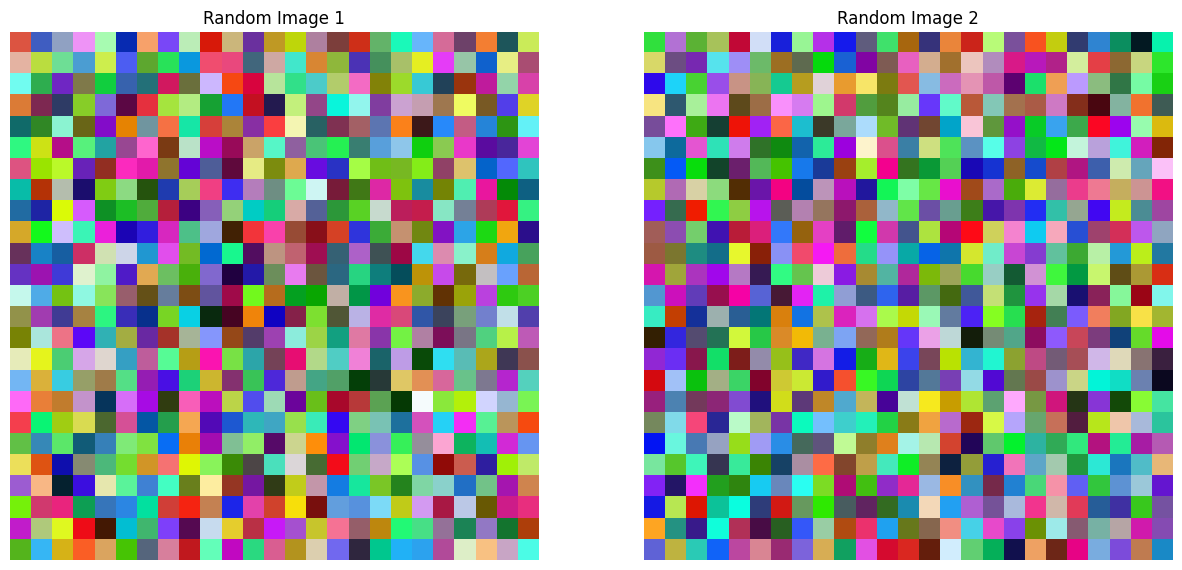

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.imshow(random_image)
plt.title("Random Image 1")
plt.axis(False)

plt.subplot(1,2,2)
plt.imshow(random_image2)
plt.title("Random Image 2")
plt.axis(False)

plt.show()

In [18]:
img_shape = (72,72,3)
data = [torch.randint(low=0, high=255, size=img_shape, dtype=torch.float) for i in range(1000)]

tensor_data = torch.stack(data, dim=0)
tensor_data.shape

torch.Size([1000, 72, 72, 3])

In [19]:
torch.reshape(tensor_data, (len(data),-1)).shape, np.prod(data[0].shape)

(torch.Size([1000, 15552]), np.int64(15552))

In [20]:
#A series of values between 0 and 100 (excluded) with a step of 5 between each pair of adjacent points. 
torch.arange(start=0,end=100, step=5)

tensor([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
        90, 95])

In [21]:
#A series of 5 values between 0 and 100 (included) with linearly separated points. 
torch.linspace(0, 100, 5)

tensor([  0.,  25.,  50.,  75., 100.])

### Zeros and Ones

In [22]:
torch.zeros((3,3), dtype=torch.int)

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]], dtype=torch.int32)

In [23]:
torch.ones(3,3, dtype=torch.float32)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

In [24]:
torch.eye(3)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [25]:
torch.eye(5,5)

tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])

### Operation on tensor

In [26]:
#The shape should be equal for the sum of 2 vectors
torch.tensor([1,2,3])+10, torch.tensor([1,2,3])+torch.tensor([4,5,6])

(tensor([11, 12, 13]), tensor([5, 7, 9]))

In [27]:
#The shape should be equal for the substraction of 2 vectors
torch.tensor([1,2,3])-10, torch.tensor([1,2,3])-torch.tensor([4,5,6])

(tensor([-9, -8, -7]), tensor([-3, -3, -3]))

In [28]:
#The shape should be equal for the multiplication (element-wise) of 2 vectors
torch.tensor([1,2,3])*10, torch.tensor([1,2,3])*torch.tensor([4,5,6])

(tensor([10, 20, 30]), tensor([ 4, 10, 18]))

Using the torch dedicated function you can end with the same results and the observations above are still applied 

In [29]:
torch.add(torch.tensor([1,2,3]), torch.tensor([4,5,6]))

tensor([5, 7, 9])

In [30]:
torch.add(torch.tensor([1,2,3]), torch.tensor(5))

tensor([6, 7, 8])

In [31]:
torch.sub(torch.tensor([1,2,3]), torch.tensor([4,5,6])), torch.subtract(torch.tensor([1,2,3]), torch.tensor([4,5,6]))

(tensor([-3, -3, -3]), tensor([-3, -3, -3]))

In [32]:
torch.mul(torch.tensor([1,2,3]), torch.tensor([4,5,6])), torch.multiply(torch.tensor([1,2,3]), torch.tensor([4,5,6]))

(tensor([ 4, 10, 18]), tensor([ 4, 10, 18]))

In [33]:
tensor_A = torch.randint(10,(4,3))
tensor_B = torch.randint(10,(3,4))
tensor_A, tensor_B

(tensor([[9, 1, 3],
         [0, 2, 8],
         [4, 3, 6],
         [7, 2, 1]]),
 tensor([[2, 9, 0, 3],
         [1, 2, 7, 7],
         [2, 6, 4, 1]]))

In [34]:
torch.matmul(tensor_A, tensor_B)

tensor([[ 25, 101,  19,  37],
        [ 18,  52,  46,  22],
        [ 23,  78,  45,  39],
        [ 18,  73,  18,  36]])

In [35]:
tensor_A @ tensor_B

tensor([[ 25, 101,  19,  37],
        [ 18,  52,  46,  22],
        [ 23,  78,  45,  39],
        [ 18,  73,  18,  36]])

In [36]:
tensor

tensor([3., 6., 9.], dtype=torch.float64)

In [37]:
%%time
# Matrix multiplication by hand 
# (avoid doing operations with for loops at all cost, they are computationally expensive)
value = 0
for i in range(len(tensor)):
  value += tensor[i] * tensor[i]
value

CPU times: user 431 μs, sys: 0 ns, total: 431 μs
Wall time: 401 μs


tensor(126., dtype=torch.float64)

In [38]:
%%time
tensor @ tensor

CPU times: user 247 μs, sys: 34 μs, total: 281 μs
Wall time: 214 μs


tensor(126., dtype=torch.float64)

In [39]:
%%time
torch.matmul(tensor,tensor)

CPU times: user 107 μs, sys: 15 μs, total: 122 μs
Wall time: 81.8 μs


tensor(126., dtype=torch.float64)

In [40]:
# Shapes need to be in the right way  
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11], 
                         [9, 12]], dtype=torch.float32)

In [41]:
try:
    torch.matmul(tensor_A, tensor_B)
except:
    print(f"ERROR : You are trying to do matrix multiplication {tuple(tensor_A.shape)} @ {tuple(tensor_B.shape)} which is not possible.")

ERROR : You are trying to do matrix multiplication (3, 2) @ (3, 2) which is not possible.


In [42]:
tensor_B.T, tensor_B

(tensor([[ 7.,  8.,  9.],
         [10., 11., 12.]]),
 tensor([[ 7., 10.],
         [ 8., 11.],
         [ 9., 12.]]))

In [43]:
try:
    print(torch.matmul(tensor_A, tensor_B.T))
except:
    print(f"ERROR : You are trying to do matrix multiplication {tuple(tensor_A.shape)} @ {tuple(tensor_B.shape)} which is not possible.")

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])


As we saw above, for operation like multiplication, substraction, there're shortcut in torch library.\
For `torch.matmul` the shortcut is `torch.mm`

In [44]:
try:
    print(torch.mm(tensor_A, tensor_B.T))
except:
    print(f"ERROR : You are trying to do matrix multiplication {tuple(tensor_A.shape)} @ {tuple(tensor_B.shape)} which is not possible.")

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])


Let play arround with `torch.nn.Linear` the function running this mathematic expression :
$$ y = x\cdot{A^T} + b $$
Where :
- `x` is a input to the layer `torch.nn.Linear`
- `A` is the weights matrix of the model
- `b` is the vector of bias
- `y` is the output of the layer `torch.nn.Linear`

In [45]:
x = tensor_A
x.shape

torch.Size([3, 2])

In [46]:
torch.manual_seed(42)

linear_func=torch.nn.Linear(in_features=2,#size of each input sample
                            out_features = 5, #size of each output sample
                            bias=True,
                            device=torch.device('cpu')
                           )

In [47]:
y = linear_func(x)

In [48]:
y

tensor([[ 2.3290,  1.2658,  0.6529,  0.5820, -0.0732],
        [ 4.5841,  2.2336,  0.6284,  0.7241,  0.1360],
        [ 6.8391,  3.2014,  0.6039,  0.8661,  0.3452]],
       grad_fn=<AddmmBackward0>)

In [49]:
softmax_func = torch.nn.Softmax(dim=1)

In [50]:
softmax_func(y)

tensor([[0.5564, 0.1921, 0.1041, 0.0970, 0.0504],
        [0.8717, 0.0831, 0.0167, 0.0184, 0.0102],
        [0.9687, 0.0255, 0.0019, 0.0025, 0.0015]], grad_fn=<SoftmaxBackward0>)

In [51]:
torch.sum(softmax_func(y), dim=1)

tensor([1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)

In [52]:
torch.manual_seed(42)

linear_func = torch.nn.Linear(in_features=int(np.prod(data[0].shape)),
                            out_features = 5,
                            bias=True,
                            device=torch.device('cpu'))

softmax_func = torch.nn.Softmax(dim=1)

In [53]:
X = tensor_data.view([len(data),-1])

Y = softmax_func(linear_func(X))

Y.shape

torch.Size([1000, 5])

In [54]:
torch.argmax(Y[0]).item(), Y[0]

(2,
 tensor([4.5638e-36, 0.0000e+00, 1.0000e+00, 7.9454e-40, 4.6274e-07],
        grad_fn=<SelectBackward0>))

 $$ \text{out}_{i} \sim \mathcal{N}(0, 1) $$

In [55]:
torch.manual_seed(237)
t = torch.randn(10)

In [56]:
t

tensor([ 2.0883,  0.4275, -1.7370, -1.0338,  0.7497, -0.2431, -0.9824,  0.8042,
         0.5562,  0.8690])

In [57]:
x =torch.ones(10)

In [58]:
y=x.view_as(x)

In [59]:
x,y

(tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [60]:
x=x+2
x,y

(tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [61]:
# Set device type
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps" # Use Apple Silicon GPU (if available)
else:
    device = "cpu" # Default to CPU if no GPU is available

device

'cpu'